# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Install dependencies (if not installed)
#!pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

## **1. Load & Explore Data**

- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues

                                                  Russian  \
count                                               11152   
unique                                              11150   
top     Проанализировано качество оказания помощи паци...   
freq                                                    2   

                                                  English  
count                                               11152  
unique                                              11144  
top     The aim of the study was to elaborate lingual ...  
freq                                                    2  
                                             Russian  \
0  Резюме Цель: Определить, в какой степени грипп...   
1  Резюме Цель: Провести экспертную процедуру опр...   
2  Резюме Цель: Определить влияние еженедельной н...   
3  Резюме Цель: Определить, явилась ли политика б...   
4  Резюме Цель: Оценить проблему туберкулеза со м...   

                                             English  
0 

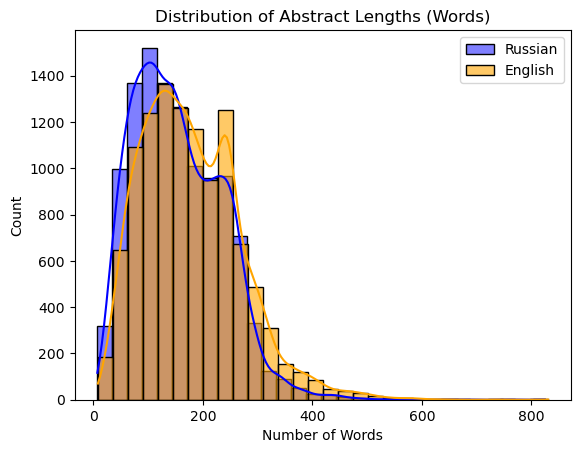

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

## **2. Preprocessing: SentencePiece Tokenization**

- Train a SentencePiece model
- Tokenize the training and test sets

In [ ]:
import sentencepiece as spm

# Train SentencePiece (if needed)
!python3 scripts/sentencepiece_train.py

In [ ]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/parallel_corpus.tsv --output data/spm_parallel_corpus.tsv

## **3. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [ ]:
# Train the model
!python3 scripts/seq2seq_train.py

## **4. Translation & Evaluation**

- Translate test data
- Evaluate performance using BLEU and chrF

In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py --hyp data/wmt_test_translations_with_beam.txt --ref data/test_reference_en.txt
print("Project setup complete! Ready for further analysis.")

## **5. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Improve handling of long sequences (segmenting abstracts)
- Fine-tune hyperparameters for better results